Laboratory 5

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%matplotlib inline

In [3]:
df_gt = pd.read_csv('./map_assignment_ground_truth.csv')
df_pred = pd.read_csv('./map_assignment_predictions.csv')

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [5]:
df_gt.shape, df_pred.shape

((13829, 7), (16662, 8))

In [6]:
len(df_gt['obj_id'].value_counts(normalize=True))

13829

In [7]:
df_gt['class'].value_counts(normalize=True)

class
Vehicle   0.958
Human     0.025
Object    0.017
Name: proportion, dtype: float64

In [8]:
df_pred['class'].value_counts(normalize=True)

class
Vehicle   0.939
Human     0.049
Object    0.013
Name: proportion, dtype: float64

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_gt['class'] = le.fit_transform(df_gt['class'])
df_pred['class'] = le.transform(df_pred['class'])

In [10]:
gt_alt = df_gt.copy()

In [11]:
gt_alt['class'].value_counts(normalize=True)
gt_alt.drop(['filename', 'obj_id'], axis=1, inplace=True)
gt_alt['class_1'] = gt_alt['class']
gt_alt.drop('class', axis=1, inplace=True)
gt_alt['difficult'] = 0
gt_alt['crowd'] = 0

In [14]:
# Label encoding
# Human: 0 - (811)
# Object: 1 - (240)
# Vehicle: 2 - (13245)

gt_alt.head()

,xmin,ymin,xmax,ymax,class_1,difficult,crowd
0,587.737,31.514,600.000,42.018,2,0,0
1,570.219,70.030,592.993,86.663,2,0,0
2,584.234,49.021,600.000,62.152,2,0,0
3,568.467,35.891,580.730,46.395,2,0,0
4,548.321,119.052,592.993,156.693,2,0,0


In [15]:
pred_alt = df_pred.copy()

In [16]:
pred_alt.drop(['filename', 'index_pred'], axis=1, inplace=True)
pred_alt['class1'] = pred_alt['class']
pred_alt['confidence'] = pred_alt['score']
pred_alt.drop(['class', 'score'], axis=1, inplace=True)

In [17]:
pred_alt.head()

,xmin,ymin,xmax,ymax,class1,confidence
0,561.244,84.549,592.645,109.890,2,1.000
1,545.757,117.406,592.049,156.095,2,1.000
2,546.727,53.184,567.341,69.941,2,0.987
3,568.682,36.319,581.258,45.801,2,0.982
4,588.587,34.530,599.382,43.370,2,0.921


In [18]:
gt_array = np.asanyarray(gt_alt)
pred_array = np.asanyarray(pred_alt)

In [19]:
gt_array.shape, pred_array.shape

((13829, 7), (16662, 6))

In [20]:
from mean_average_precision import MetricBuilder
from sklearn.metrics import PrecisionRecallDisplay

In [21]:
metric_fn = MetricBuilder.build_evaluation_metric("map_2d", async_mode=True, num_classes=1)
for i in range(10):
    metric_fn.add(pred_array, gt_array)
metric_dict = metric_fn.value(iou_thresholds=0.5)

print("mAP at IoU=0.5:", metric_dict['mAP'])

mAP at IoU=0.5: 0.75037974


In [22]:
len(metric_dict[0.5][0]['precision'])

8110

In [23]:
len(metric_dict[0.5][0]['recall'])

8110

In [24]:
prec = metric_dict[0.5][0]['precision']
recall = metric_dict[0.5][0]['recall']

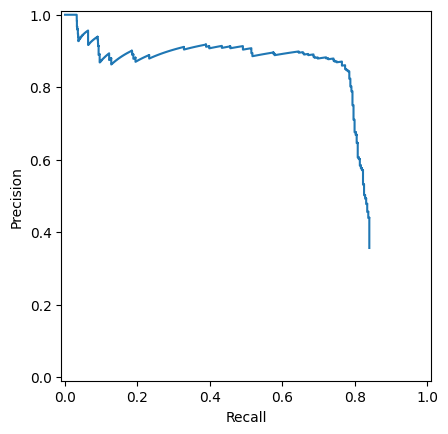

In [26]:
pr_display = PrecisionRecallDisplay(precision=prec, recall=recall).plot()

PR-graph per class

In [27]:
def processPrecisionRecall(class_id):
    gt_temp = gt_alt[gt_alt['class_1'] == class_id].copy()
    pred_temp = pred_alt[pred_alt['class1'] == class_id].copy()

    gt_temp.loc[:, 'class_1'] = 0
    pred_temp.loc[:, 'class1'] = 0

    gt_array = np.asarray(gt_temp)
    pred_array = np.asarray(pred_temp)
    
    metric_fn = MetricBuilder.build_evaluation_metric("map_2d", async_mode=True, num_classes=1)

    # for i in range(10):
    metric_fn.add(pred_array, gt_array)

    print(f"{gt_array.shape}, {pred_array.shape}")
    
    metric_dict = metric_fn.value(iou_thresholds=0.5)

    prec_temp = metric_dict[0.5][0]['precision']
    recall_temp = metric_dict[0.5][0]['recall']

    return prec_temp, recall_temp

In [37]:
def customPrecisionRecallShow(precision, recall, class_id):
    plt.plot(recall, precision, label=f'Class {class_id}')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision and Recall for Class {class_id}")
    plt.legend()
    plt.show()

Human 

(344, 7), (811, 6)


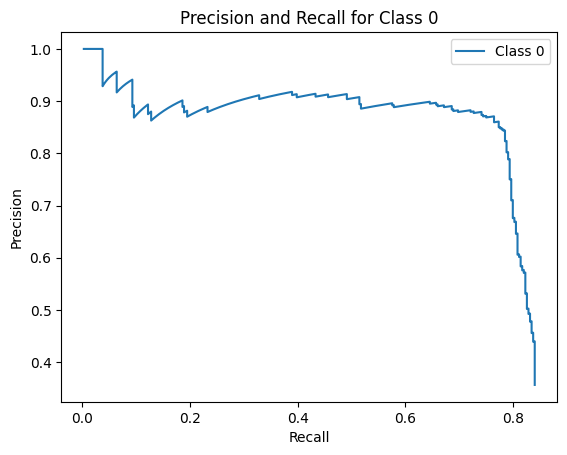

In [29]:
human_id = 0
prec_human, recall_human = processPrecisionRecall(human_id)
customPrecisionRecallShow(precision=prec_human, recall=recall_human, class_id=human_id)
# PrecisionRecallDisplay(precision=prec_human, recall=recall_human).plot(label=f'Class {human_id}')

# This plot shows that the model works well on a small number of samples, 
# but as we try to increase recall, it gradually loses accuracy.

Object

(240, 7), (209, 6)


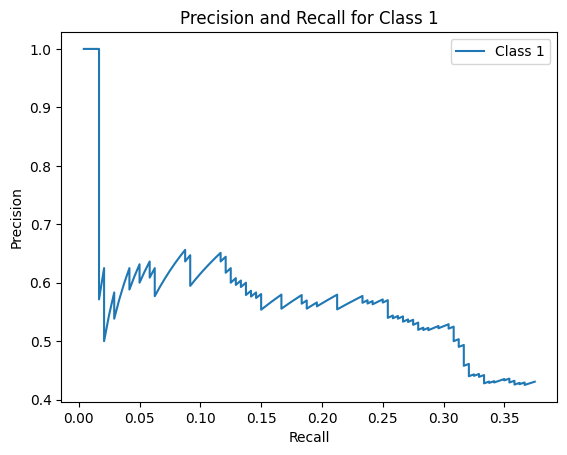

In [30]:
object_id = 1
prec_object, recall_object = processPrecisionRecall(object_id)
customPrecisionRecallShow(precision=prec_object, recall=recall_object, class_id=object_id)
# PrecisionRecallDisplay(precision=prec_object, recall=recall_object).plot(label=f'Class {object_id}')

# This plot shows that the model has trouble accurately recognizing samples of class 1. 
# As we trying to increase recall, the accuracy drops rapidly, indicating that the model is not able to recognize this class.

Vehicle

(13245, 7), (15642, 6)


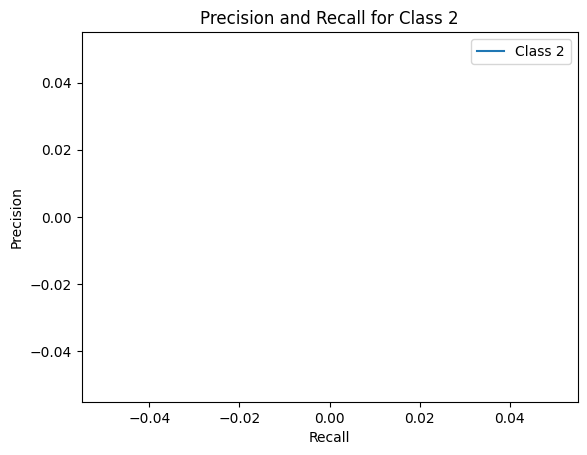

In [38]:
vehicle_id = 2
prec_vehicle, recall_vehicle = processPrecisionRecall(vehicle_id)
customPrecisionRecallShow(precision=prec_vehicle, recall=recall_vehicle, class_id=vehicle_id)
# PrecisionRecallDisplay(precision=prec_vehicle, recall=recall_vehicle).plot(label=f'Class {vehicle_id}')

In [32]:
thresholds = np.arange(0, 1.1, 0.1)

In [33]:
def computePrecisionRecallAtThresholds(class_id):
    gt_temp = gt_alt[gt_alt['class_1'] == class_id].copy()
    pred_temp = pred_alt[pred_alt['class1'] == class_id].copy()
    gt_temp.loc[:, 'class_1'] = 0
    pred_temp.loc[:, 'class1'] = 0

    precisions = []
    recalls = []

    for threshold in thresholds:
        # filter
        pred_threshold = pred_temp[pred_temp['confidence'] >= threshold].copy()
        gt_array = np.asarray(gt_temp)
        pred_array = np.asarray(pred_threshold)

        metric_fn = MetricBuilder.build_evaluation_metric("map_2d", async_mode=True, num_classes=1)
        metric_fn.add(pred_array, gt_array)

        metric_dict = metric_fn.value(iou_thresholds=0.5)
        if len(metric_dict[0.5][0]['precision']) > 0:
            precision = metric_dict[0.5][0]['precision'][-1]
        else:
            precision = 0
        if len(metric_dict[0.5][0]['recall']) > 0:
            recall = metric_dict[0.5][0]['recall'][-1]
        else:
            recall = 0

        precisions.append(precision)
        recalls.append(recall)

    return precisions, recalls


In [34]:
def customPrecisionRecallThresholdShow(precisions, recalls, class_id):
    plt.figure(figsize=(10, 5))
    
    plt.plot(thresholds, precisions, label='Precision', color='blue')
    plt.plot(thresholds, recalls, label='Recall', color='orange')
    
    plt.xticks(thresholds)
    
    plt.xlabel("Threshold")
    plt.ylabel("Metric Value")
    plt.title(f"Precision and recall as functions of threshold for class {class_id}")
    plt.legend()
    plt.show()

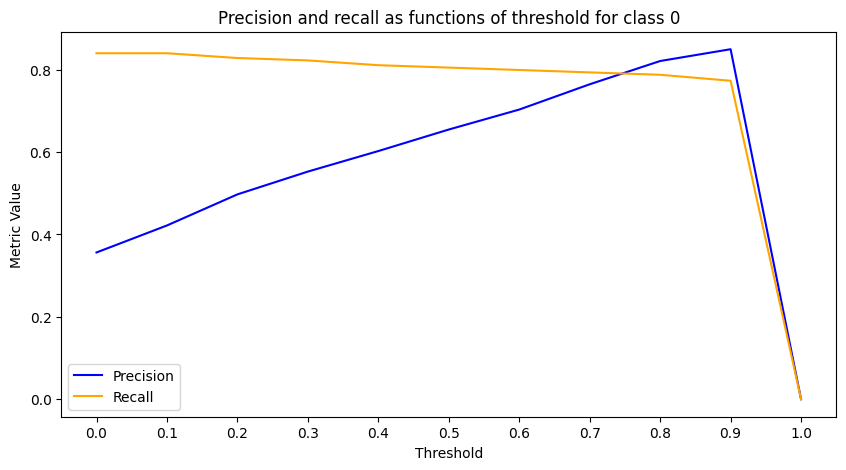

In [35]:

precisions_human, recalls_human = computePrecisionRecallAtThresholds(human_id)
customPrecisionRecallThresholdShow(precisions_human, recalls_human, human_id)
# For Class 0, it is optimal to use a threshold in the range of 0.7–0.8, where precision and recall are in a good balance. 
# At low thresholds, the model provides high recall, but low precision, and at high thresholds, the model has high precision, 
# but the recall drops dramatically.

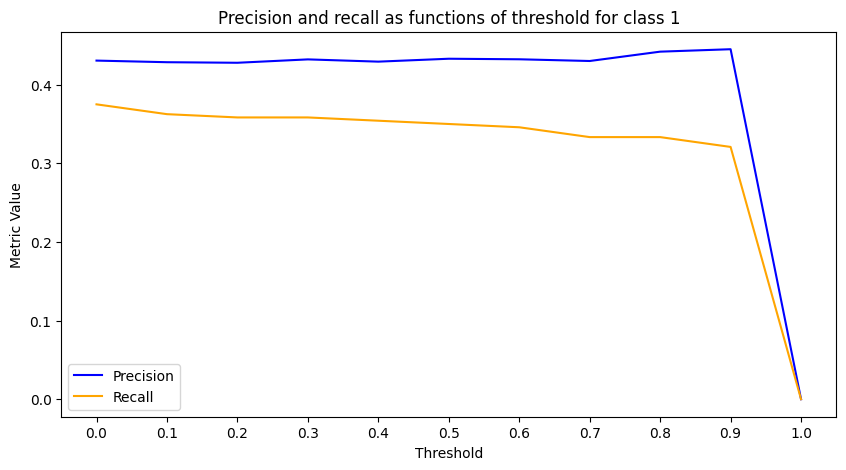

In [36]:
precisions_object, recalls_object = computePrecisionRecallAtThresholds(object_id)
customPrecisionRecallThresholdShow(precisions_object, recalls_object, object_id)
# The optimal threshold for class 1 depends on the specific application.

In [ ]:
precisions_vehicle, recalls_vehicle = computePrecisionRecallAtThresholds(vehicle_id)
customPrecisionRecallThresholdShow(precisions_vehicle, recalls_vehicle, vehicle_id)
# after 25 min my laptop crashed